In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df1 = pd.read_csv('Unemployment in India.csv')

### 1. Data cleaning and preparation

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Clean column names (remove spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Convert Date column
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

# Merge datasets
df = pd.concat([df1, df2], ignore_index=True)

# Rename column for easier use
df.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate'}, inplace=True)

# Sort values
df = df.sort_values(by='Date')

# Check missing values
print(df.isnull().sum())

Region                                      28
Date                                        28
Frequency                                   28
Unemployment_Rate                           28
Estimated Employed                          28
Estimated Labour Participation Rate (%)     28
Area                                       295
Region.1                                   768
longitude                                  768
latitude                                   768
dtype: int64


### 2. Exploratory Data Analysis (EDA)

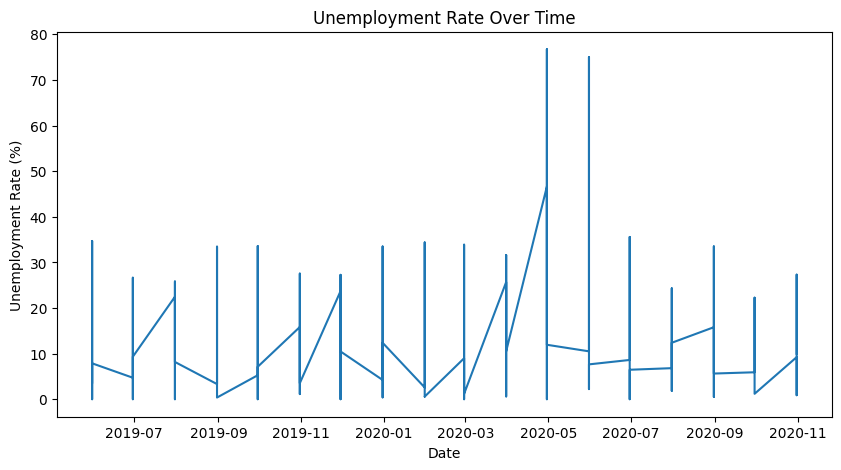

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Unemployment_Rate'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

#### Monthly Trend

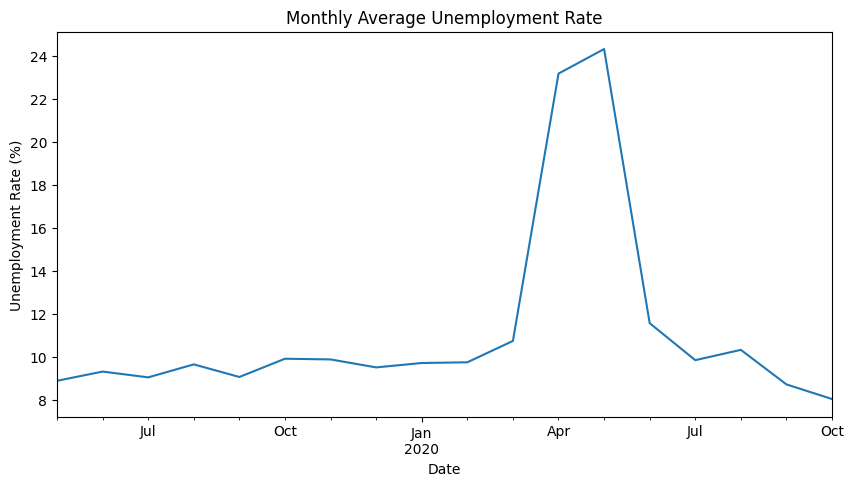

In [11]:
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Unemployment_Rate'].mean()

monthly_avg.plot(figsize=(10,5), title="Monthly Average Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.show()

#### Region Wise Analysis

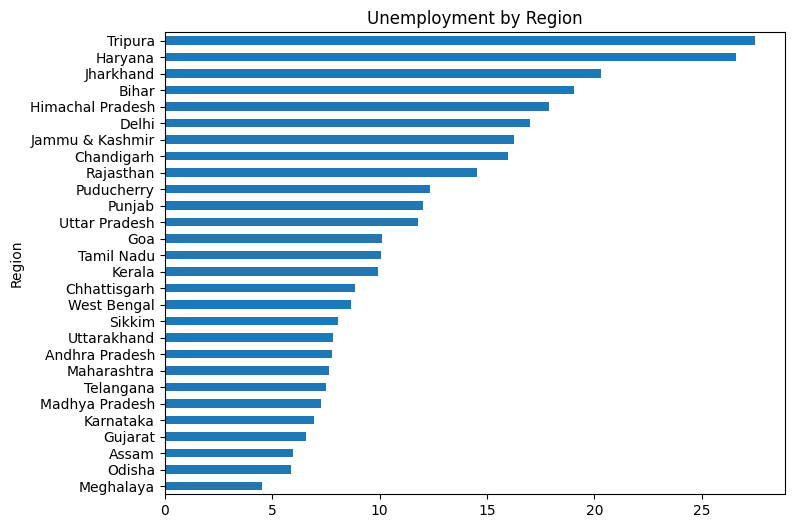

In [12]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values()

region_avg.plot(kind='barh', figsize=(8,6), title="Unemployment by Region")
plt.show()

### 3. Covid 19 Impact Analysis

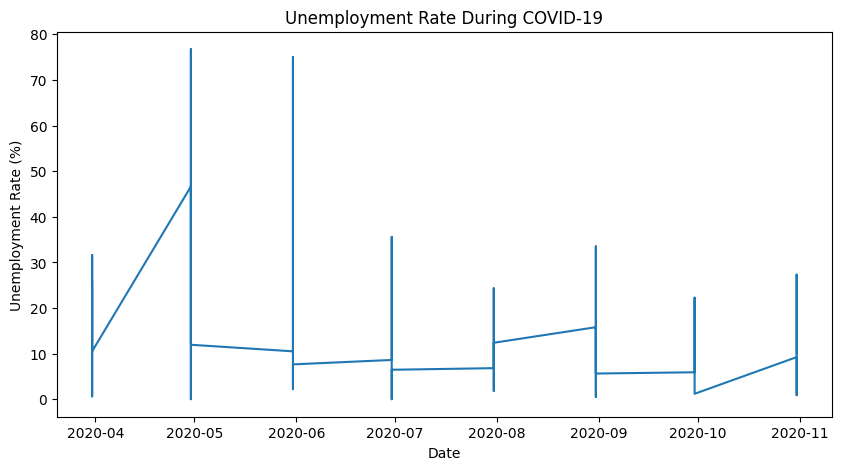

In [13]:
covid_period = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-12-31')]

plt.figure(figsize=(10,5))
plt.plot(covid_period['Date'], covid_period['Unemployment_Rate'])
plt.title("Unemployment Rate During COVID-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

### 4. Key Insights

### Impact of COVID-19
##### * There was a sharp spike in unemployment around March-May 2020
##### * This aligns with lockdowns and economic shutdowns
##### * Many sectors (especially informal jobs) were heavily affected

### Trend Observations
##### * Unemployment was relatively stable before 2020
##### * A sudden disruption occurred during COVID
##### * After peak months, there was a gradual recovery

### Seasonality Patterns
##### * Slight fluctuations across months suggest:
##### * Agricultural cycles
##### * Festive hiring periods
##### * However, COVID disrupted normal seasonal patterns

### Regional Differences
##### * Some regions consistently show:
##### * Higher unemployment rates (structural issues)
##### * Others are more stable (better economic activity)

### 5. Policy Recommendations

### Government should:
##### * Strengthen social safety nets during crises
##### * Invest in job creation programs
##### * Support small and medium businesses (SMEs)
##### * Promote remote work and digital jobs
##### * Improve labor market resilience for future shocks

### 6. Final Conclusion 

#### The analysis shows that unemployment trends were significantly impacted by COVID-19, with a sharp rise during lockdown periods. While recovery began afterward, the crisis exposed vulnerabilities in the labor market. Data-driven policy decisions are essential to mitigate such economic shocks in the future.